# GradCam

In [1]:
import sys
import os

sys.path.append(os.path.abspath('..'))

from train import task
import grad_cam
import pandas as pd

## Data

In [2]:
hospital_data = grad_cam.get_train_data()
df_train_combined = pd.concat([hospital_data[h]['train'] for h in hospital_data], ignore_index=True)

## Compute GradCam

In [3]:
from torchvision import models
from baseline import centralized_utils

In [4]:
weights = models.DenseNet121_Weights.DEFAULT
preprocess_transform = weights.transforms()
preprocess_transform

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [5]:
images = []
heatmaps = []
true_classes = []
pred_classes = []

n_classes = 14
model = grad_cam.DenseNet121(n_classes) # change here
target_layer = model.densenet.features.denseblock4.denselayer16.conv2

for target_label in task.DISEASE_LABELS:
    image, label = grad_cam.get_label_sample(df_train_combined, target_label)
    images.append(image)
    true_classes.append(label)
    image_pre = preprocess_transform(image)
    heatmap, pred = grad_cam.compute_heatmap(model, target_layer, image_pre)
    heatmaps.append(heatmap)
    pred_classes.append(grad_cam.IDX_TO_LABEL[pred])

## Plot GradCam

In [6]:
import random

In [7]:
idx = random.randint(0, len(images) - 1)

example_image = images[idx]
example_label = true_classes[idx]
multi_hot_label = grad_cam.get_multi_hot_label(example_label)
example_label, multi_hot_label

(array(['Cardiomegaly'], dtype=object),
 tensor([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]))

In [8]:
image_pre = preprocess_transform(example_image)
image_pre.shape

torch.Size([3, 224, 224])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3262744].


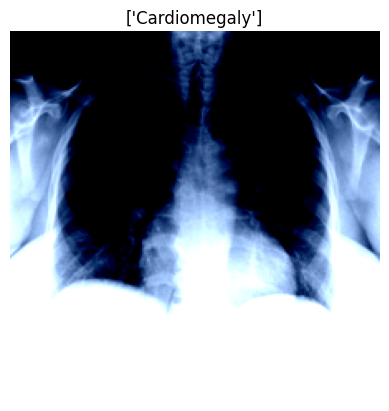

In [9]:
centralized_utils.show_xray(image_pre.permute(1, 2, 0), multi_hot_label)

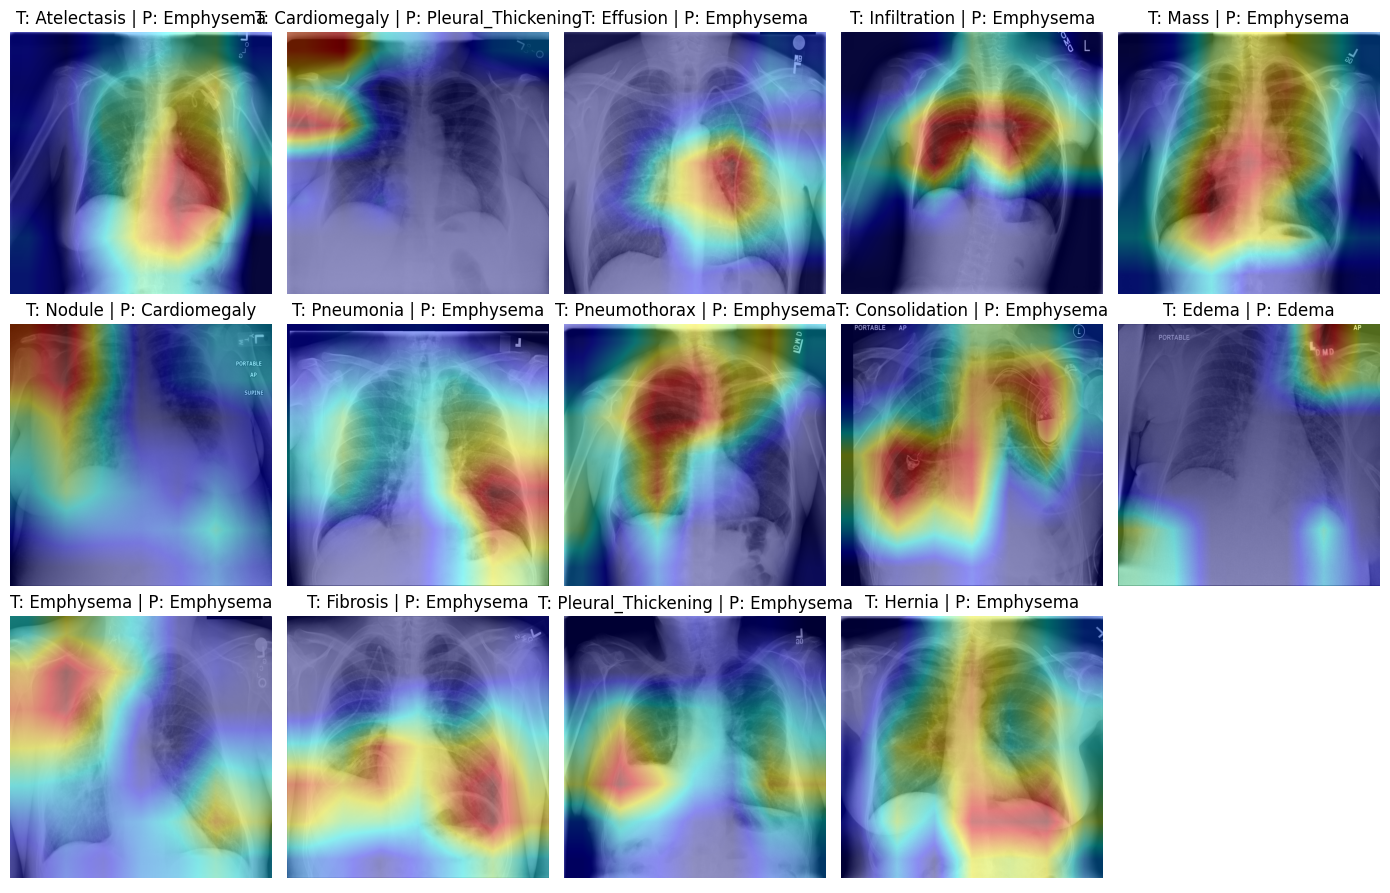

In [10]:
grad_cam.plot_grad_cam_grid(images, heatmaps, true_classes, pred_classes)